# LSTM untuk Prediksi Dinamika Limbah Plastik
## Berdasarkan Data Hidrodinamika — Contoh Data Sintetis

**Sebelum mulai:**
- Aktifkan GPU: **Runtime → Change runtime type → T4 GPU → Save**
- Jalankan setiap sel dengan **Shift + Enter** dari atas ke bawah

---
**Catatan:** Notebook ini menggunakan **data sintetis** yang dibuat berdasarkan pola fisik nyata:
- Siklus pasut semi-diurnal (2x per hari, periode ~12.4 jam)
- Siklus musiman (angin musim barat & timur)
- Korelasi realistis antara hidrodinamika dan konsentrasi plastik
- Noise acak untuk mensimulasikan variabilitas lapangan


## Sel 1 — Install & Import Library

In [30]:
# Install library tambahan jika belum tersedia
# (TensorFlow, NumPy, Pandas, Matplotlib sudah tersedia di Colab)
!pip install seaborn scikit-learn --quiet

# ===== IMPORT SEMUA LIBRARY =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    Bidirectional, LayerNormalization
)
from tensorflow.keras.models import Model

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Cek versi & GPU
print('=' * 50)
print('  Konfigurasi Sistem')
print('=' * 50)
import sys
print(f'Python versi   : {sys.version.split()[0]}')
print(f'TensorFlow     : {tf.__version__}')
print(f'NumPy          : {np.__version__}')
print(f'Pandas         : {pd.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU tersedia   : {"YA — " + gpus[0].name if gpus else "TIDAK (CPU mode)"}')
print('=' * 50)

  Konfigurasi Sistem
Python versi   : 3.12.13
TensorFlow     : 2.20.0
NumPy          : 2.0.2
Pandas         : 2.2.2
GPU tersedia   : YA — /physical_device:GPU:0


## Sel 2 — Buat Data Hidrodinamika Sintetis

Data dibuat berdasarkan formula fisik nyata:
- Pasut mengikuti superposisi gelombang M2 dan S2
- Arus dipengaruhi gradien pasut + angin musiman
- Konsentrasi plastik berkorelasi dengan kecepatan arus dan curah hujan

In [31]:
def buat_data_hidrodinamika(
    tanggal_mulai='2025-01-01',
    n_hari=365,
    resolusi_jam=1
):
    """
    Membuat dataset hidrodinamika sintetis realistis.

    Parameter:
    - tanggal_mulai : string 'YYYY-MM-DD'
    - n_hari        : jumlah hari data (default 365 = 1 tahun)
    - resolusi_jam  : interval data dalam jam (1 = per jam)

    Return:
    - df : DataFrame dengan semua variabel hidrodinamika
    """

    # Buat index waktu
    n_titik = n_hari * 24 // resolusi_jam
    waktu   = pd.date_range(
        start=tanggal_mulai,
        periods=n_titik,
        freq=f'{resolusi_jam}h'
    )
    t = np.arange(n_titik)  # indeks waktu integer

    print(f'Membuat {n_titik:,} baris data ({n_hari} hari, resolusi {resolusi_jam} jam)...')

    # ============================================================
    # 1. PASUT (Tidal Height)
    # Superposisi komponen M2 (12.42 jam) + S2 (12.00 jam)
    # + komponen K1 (23.93 jam) untuk pola diurnal
    # ============================================================
    T_M2  = 12.42  # periode komponen utama pasut (jam)
    T_S2  = 12.00  # komponen solar semi-diurnal
    T_K1  = 23.93  # komponen lunisolar diurnal

    noise_pasut   = np.random.normal(0, 0.05, n_titik)
    tinggi_pasut  = (
        1.20 * np.sin(2 * np.pi * t / T_M2) +
        0.45 * np.sin(2 * np.pi * t / T_S2 + np.pi/6) +
        0.25 * np.sin(2 * np.pi * t / T_K1) +
        noise_pasut
    )

    # ============================================================
    # 2. ARUS LAUT (U dan V komponen)
    # Arus utama driven by pasut + pengaruh angin musiman
    # ============================================================
    T_musim = 365.25 * 24  # periode musiman (jam)

    # Arus komponen U (timur-barat), dipengaruhi gradien pasut
    u_arus = (
        0.35 * np.cos(2 * np.pi * t / T_M2) +
        0.12 * np.cos(2 * np.pi * t / T_S2) +
        0.08 * np.sin(2 * np.pi * t / T_musim) +  # variasi musiman
        np.random.normal(0, 0.04, n_titik)
    )

    # Arus komponen V (utara-selatan)
    v_arus = (
        0.28 * np.sin(2 * np.pi * t / T_M2 + np.pi/4) +
        0.10 * np.sin(2 * np.pi * t / T_S2) +
        0.06 * np.cos(2 * np.pi * t / T_musim) +
        np.random.normal(0, 0.03, n_titik)
    )

    # Magnitude arus (resultant)
    mag_arus = np.sqrt(u_arus**2 + v_arus**2)

    # ============================================================
    # 3. GELOMBANG LAUT
    # Tinggi signifikan (Hs) dan periode puncak (Tp)
    # Lebih tinggi di musim barat (bulan 11-3)
    # ============================================================
    bulan = waktu.month.values

    # Faktor musim: musim barat lebih bergelombang
    faktor_musim = np.where(
        (bulan >= 11) | (bulan <= 3),
        1.8,   # musim barat
        1.0    # musim timur/peralihan
    )

    Hs = (
        faktor_musim * 0.6 *
        (1 + 0.3 * np.sin(2 * np.pi * t / (6 * 24))) +  # variasi 6 harian
        np.abs(np.random.normal(0, 0.15, n_titik))
    )
    Hs = np.clip(Hs, 0.05, 4.5)  # batas fisik realistis

    Tp = 4.5 + 2.5 * (Hs / Hs.max()) + np.random.normal(0, 0.5, n_titik)
    Tp = np.clip(Tp, 3.0, 14.0)

    # ============================================================
    # 4. ANGIN
    # Pola musim barat (NW) dan musim timur (SE) khas Indonesia
    # ============================================================
    kec_angin = (
        faktor_musim * 3.5 +
        1.5 * np.sin(2 * np.pi * t / (12 * 24)) +  # variasi diurnal angin darat-laut
        np.abs(np.random.normal(0, 0.8, n_titik))
    )
    kec_angin = np.clip(kec_angin, 0.5, 18.0)

    # Arah angin: musim barat ~315° (NW), musim timur ~135° (SE)
    arah_base = np.where(
        (bulan >= 11) | (bulan <= 3),
        315.0,  # musim barat
        135.0   # musim timur
    )
    arah_angin = (arah_base + np.random.normal(0, 25, n_titik)) % 360

    # Encoding sirkular arah angin
    angin_sin = np.sin(np.radians(arah_angin))
    angin_cos = np.cos(np.radians(arah_angin))

    # ============================================================
    # 5. CURAH HUJAN
    # Musim hujan (Nov-Mar), musim kemarau (Jun-Sep)
    # ============================================================
    intensitas_hujan = np.where(
        (bulan >= 11) | (bulan <= 3),
        0.4,   # peluang hujan lebih tinggi musim basah
        0.12   # peluang hujan lebih rendah musim kemarau
    )

    # Simulasi kejadian hujan diskrit
    kejadian_hujan = np.random.random(n_titik) < intensitas_hujan / resolusi_jam
    curah_hujan = np.where(
        kejadian_hujan,
        np.abs(np.random.exponential(8.0, n_titik)),  # intensitas eksponensial
        0.0
    )
    # Akumulasi hujan menjadi sedikit lebih smooth
    curah_hujan = pd.Series(curah_hujan).rolling(3, min_periods=1).mean().values

    # ============================================================
    # 6. KONSENTRASI PLASTIK (TARGET)
    # Dipengaruhi oleh: arus kuat, hujan deras, pasut rendah
    # + tren musiman + noise acak lapangan
    # ============================================================

    # Base: konsentrasi rata-rata ~250 partikel/m³
    base_plastik = 250.0

    # Kontribusi setiap faktor
    efek_arus    = 180 * mag_arus               # arus kuat mobilisasi plastik
    efek_hujan   = 25  * np.log1p(curah_hujan)  # hujan bawa plastik dari daratan
    efek_pasut   = -60 * tinggi_pasut           # pasut tinggi = pengenceran
    efek_musim   = 80  * np.sin(2 * np.pi * t / T_musim + np.pi)  # puncak di musim hujan
    efek_gelombang = 30 * Hs                    # gelombang aduk plastik permukaan

    # Lag effect: plastik tidak langsung muncul saat hujan (delay 3-6 jam)
    lag_hujan = pd.Series(efek_hujan).shift(4).fillna(0).values

    # Gabungkan semua efek
    konsentrasi_plastik = (
        base_plastik +
        efek_arus +
        lag_hujan +
        efek_pasut +
        efek_musim +
        efek_gelombang +
        np.random.normal(0, 30, n_titik)  # noise lapangan
    )

    # Plastik tidak bisa negatif
    konsentrasi_plastik = np.clip(konsentrasi_plastik, 10.0, 1200.0)

    # ============================================================
    # 7. ENCODING FITUR WAKTU (sirkular)
    # ============================================================
    jam      = waktu.hour.values
    bulan_val = waktu.month.values

    jam_sin   = np.sin(2 * np.pi * jam / 24)
    jam_cos   = np.cos(2 * np.pi * jam / 24)
    bulan_sin = np.sin(2 * np.pi * bulan_val / 12)
    bulan_cos = np.cos(2 * np.pi * bulan_val / 12)

    # ============================================================
    # 8. SUSUN DATAFRAME
    # ============================================================
    df = pd.DataFrame({
        'datetime'             : waktu,
        'tinggi_pasut'         : np.round(tinggi_pasut, 3),
        'u_arus'               : np.round(u_arus, 4),
        'v_arus'               : np.round(v_arus, 4),
        'mag_arus'             : np.round(mag_arus, 4),
        'Hs_gelombang'         : np.round(Hs, 3),
        'Tp_gelombang'         : np.round(Tp, 2),
        'kec_angin'            : np.round(kec_angin, 2),
        'arah_angin'           : np.round(arah_angin, 1),
        'angin_sin'            : np.round(angin_sin, 4),
        'angin_cos'            : np.round(angin_cos, 4),
        'curah_hujan'          : np.round(curah_hujan, 2),
        'jam_sin'              : np.round(jam_sin, 4),
        'jam_cos'              : np.round(jam_cos, 4),
        'bulan_sin'            : np.round(bulan_sin, 4),
        'bulan_cos'            : np.round(bulan_cos, 4),
        'konsentrasi_plastik'  : np.round(konsentrasi_plastik, 2),
    })

    df = df.set_index('datetime')
    return df


# ===== BUAT DATA =====
df = buat_data_hidrodinamika(
    tanggal_mulai='2025-01-01',
    n_hari=365,
    resolusi_jam=1
)

# Simpan ke CSV
df.to_csv('data_hidrodinamika_sintetis.csv')

print(f'\nDataset berhasil dibuat!')
print(f'Ukuran        : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'Periode       : {df.index[0].date()} sampai {df.index[-1].date()}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\n{df.head(5).to_string()}')

Membuat 8,760 baris data (365 hari, resolusi 1 jam)...

Dataset berhasil dibuat!
Ukuran        : 8,760 baris x 16 kolom
Periode       : 2025-01-01 sampai 2025-12-31
Missing values: 0

                     tinggi_pasut  u_arus  v_arus  mag_arus  Hs_gelombang  Tp_gelombang  kec_angin  arah_angin  angin_sin  angin_cos  curah_hujan  jam_sin  jam_cos  bulan_sin  bulan_cos  konsentrasi_plastik
datetime                                                                                                                                                                                                      
2025-01-01 00:00:00         0.250  0.5089  0.2616    0.5722         1.242          5.94       7.21       324.2    -0.5853     0.8108         9.40   0.0000   1.0000        0.5      0.866               385.72
2025-01-01 01:00:00         1.029  0.3583  0.4007    0.5376         1.211          6.43       6.85       317.6    -0.6741     0.7386         4.70   0.2588   0.9659        0.5      0.866          

## Sel 3 — Statistik Deskriptif

In [32]:
print('Statistik Deskriptif Dataset Hidrodinamika:')
print('=' * 70)

stats = df.describe().T
stats['range'] = stats['max'] - stats['min']
print(stats[['mean', 'std', 'min', 'max', 'range']].round(3).to_string())

print('\nKorelasi dengan Konsentrasi Plastik (Target):')
print('-' * 40)
korelasi = df.corr()['konsentrasi_plastik'].sort_values(ascending=False)
for fitur, nilai in korelasi.items():
    if fitur != 'konsentrasi_plastik':
        bar = '#' * int(abs(nilai) * 20)
        arah = '+' if nilai >= 0 else '-'
        print(f'  {fitur:25s}: {arah}{abs(nilai):.3f}  {bar}')

Statistik Deskriptif Dataset Hidrodinamika:
                        mean     std     min      max    range
tinggi_pasut           0.000   0.922  -2.013    1.973    3.986
u_arus                 0.000   0.270  -0.683    0.632    1.316
v_arus                -0.000   0.216  -0.477    0.483    0.960
mag_arus               0.322   0.125   0.010    0.698    0.688
Hs_gelombang           0.920   0.308   0.421    1.904    1.483
Tp_gelombang           5.711   0.635   3.460    8.140    4.680
kec_angin              5.304   1.812   2.020   10.390    8.370
arah_angin           203.171  93.748   0.000  360.000  360.000
angin_sin              0.115   0.696  -1.000    1.000    2.000
angin_cos             -0.107   0.700  -1.000    1.000    2.000
curah_hujan            1.833   3.043   0.000   31.300   31.300
jam_sin                0.000   0.707  -1.000    1.000    2.000
jam_cos               -0.000   0.707  -1.000    1.000    2.000
bulan_sin             -0.005   0.706  -1.000    1.000    2.000
bulan_cos  

## Sel 4 — Visualisasi Data (EDA)

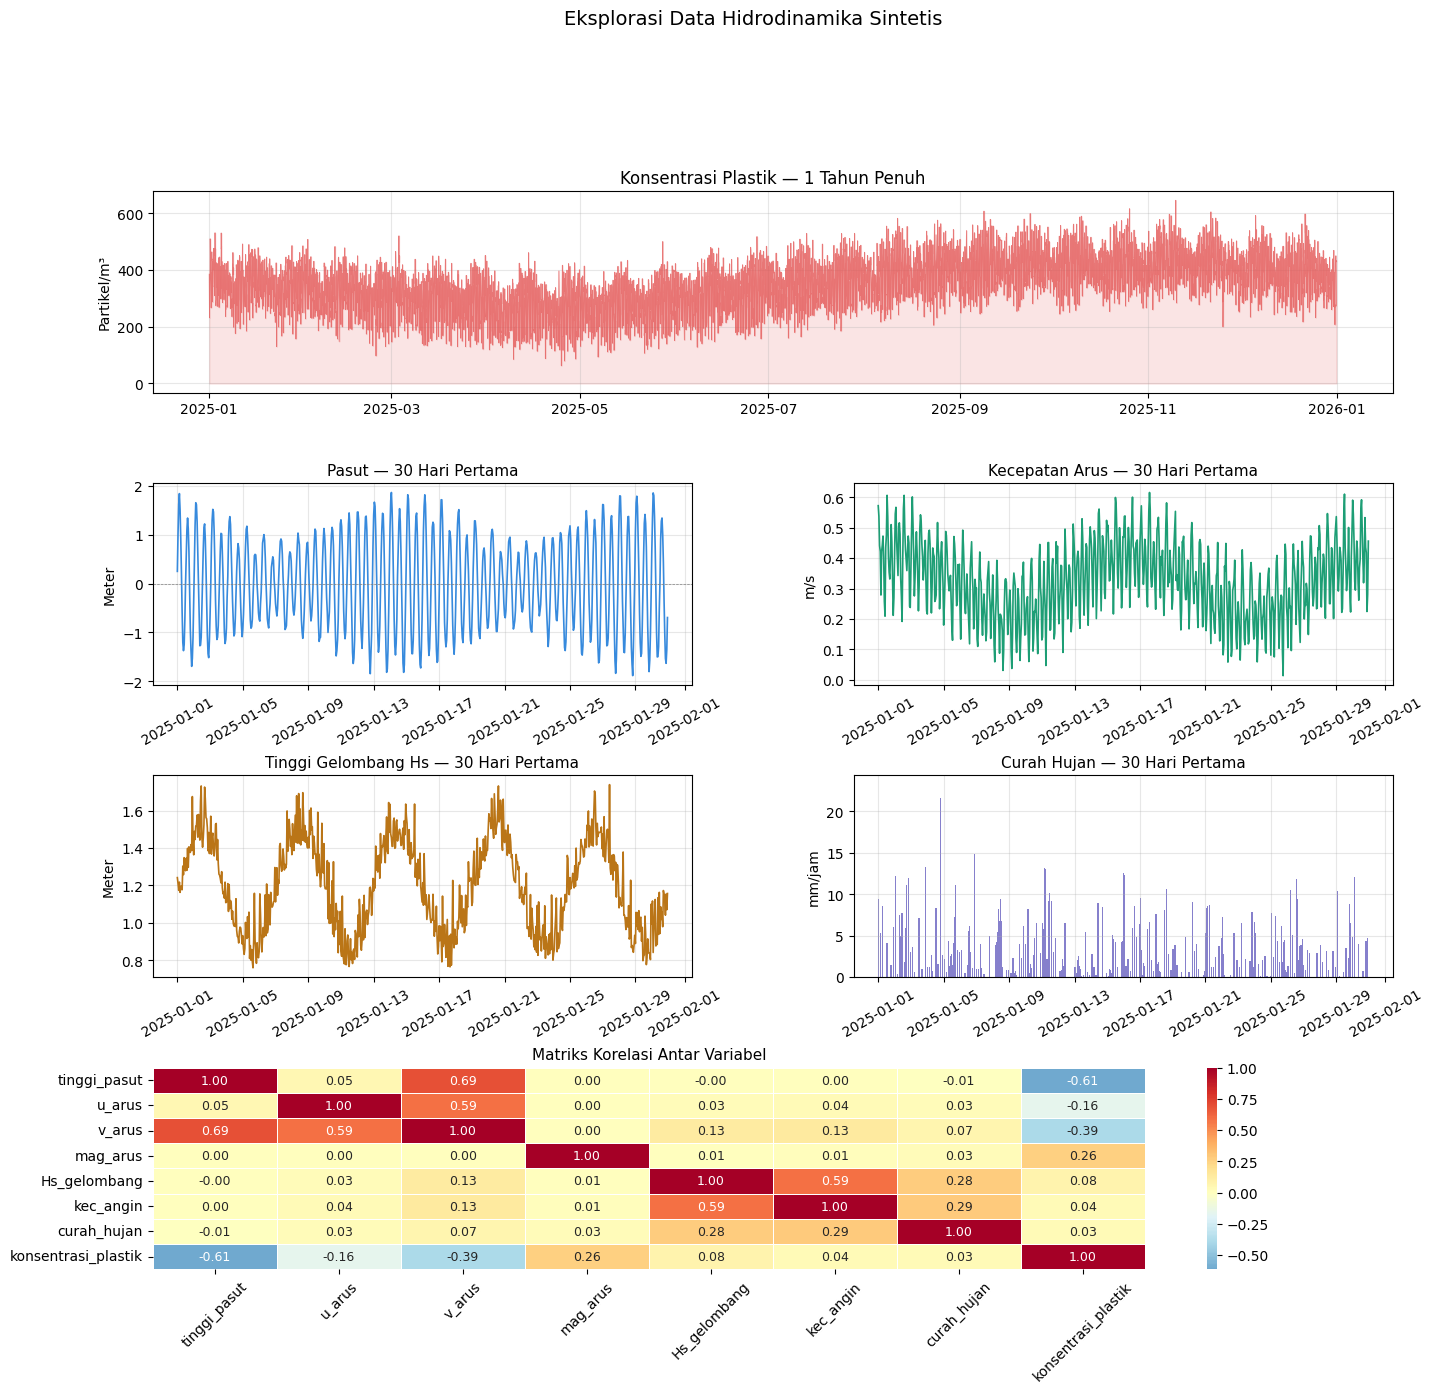

Visualisasi EDA selesai!


In [33]:
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

# Ambil 30 hari pertama untuk detail
df_30 = df.iloc[:30*24]

# 1. Konsentrasi plastik (1 tahun)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['konsentrasi_plastik'], color='#E24B4A', lw=0.6, alpha=0.7)
ax1.fill_between(df.index, df['konsentrasi_plastik'],
                 alpha=0.15, color='#E24B4A')
ax1.set_title('Konsentrasi Plastik — 1 Tahun Penuh', fontsize=12)
ax1.set_ylabel('Partikel/m³')
ax1.grid(True, alpha=0.3)

# 2. Tinggi pasut (30 hari)
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df_30.index, df_30['tinggi_pasut'], color='#378ADD', lw=1.2)
ax2.axhline(0, color='gray', lw=0.5, linestyle='--')
ax2.set_title('Pasut — 30 Hari Pertama', fontsize=11)
ax2.set_ylabel('Meter')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=30)

# 3. Magnitude arus (30 hari)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df_30.index, df_30['mag_arus'], color='#1D9E75', lw=1.2)
ax3.set_title('Kecepatan Arus — 30 Hari Pertama', fontsize=11)
ax3.set_ylabel('m/s')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=30)

# 4. Tinggi gelombang (30 hari)
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(df_30.index, df_30['Hs_gelombang'], color='#BA7517', lw=1.2)
ax4.set_title('Tinggi Gelombang Hs — 30 Hari Pertama', fontsize=11)
ax4.set_ylabel('Meter')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=30)

# 5. Curah hujan (30 hari)
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(df_30.index, df_30['curah_hujan'],
        color='#534AB7', width=0.03, alpha=0.7)
ax5.set_title('Curah Hujan — 30 Hari Pertama', fontsize=11)
ax5.set_ylabel('mm/jam')
ax5.grid(True, alpha=0.3)
ax5.tick_params(axis='x', rotation=30)

# 6. Heatmap korelasi
ax6 = fig.add_subplot(gs[3, :])
fitur_korelasi = [
    'tinggi_pasut', 'u_arus', 'v_arus', 'mag_arus',
    'Hs_gelombang', 'kec_angin', 'curah_hujan', 'konsentrasi_plastik'
]
corr_matrix = df[fitur_korelasi].corr()
sns.heatmap(
    corr_matrix,
    ax=ax6, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0,
    linewidths=0.5, annot_kws={'size': 9}
)
ax6.set_title('Matriks Korelasi Antar Variabel', fontsize=11)
ax6.tick_params(axis='x', rotation=45)

plt.suptitle('Eksplorasi Data Hidrodinamika Sintetis', fontsize=14, y=1.01)
plt.savefig('eda_hidrodinamika.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi EDA selesai!')

## Sel 5 — Preprocessing: Normalisasi & Sliding Window

In [34]:
# ===== PILIH FITUR INPUT DAN TARGET =====
FITUR_INPUT = [
    'tinggi_pasut',
    'u_arus', 'v_arus', 'mag_arus',
    'Hs_gelombang', 'Tp_gelombang',
    'kec_angin', 'angin_sin', 'angin_cos',
    'curah_hujan',
    'jam_sin', 'jam_cos',
    'bulan_sin', 'bulan_cos',
    'konsentrasi_plastik',  # juga jadi input (autoregressive)
]
TARGET = 'konsentrasi_plastik'

# ===== PARAMETER SLIDING WINDOW =====
WINDOW  = 168   # pakai data 48 jam terakhir sebagai input
HORIZON = 168   # prediksi 24 jam ke depan

print(f'Fitur input    : {len(FITUR_INPUT)} variabel')
print(f'Window size    : {WINDOW} jam')
print(f'Horizon        : {HORIZON} jam')

# ===== NORMALISASI MINMAX =====
# Scaler terpisah untuk X dan y agar inverse transform mudah
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_data = df[FITUR_INPUT].values
y_data = df[[TARGET]].values

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

print(f'\nRange setelah normalisasi:')
print(f'  X: {X_scaled.min():.4f} - {X_scaled.max():.4f}')
print(f'  y: {y_scaled.min():.4f} - {y_scaled.max():.4f}')

# ===== BUAT SEQUENCES (SLIDING WINDOW) =====
def buat_sequences(X, y, window, horizon):
    """
    Mengubah data time series menjadi pasangan input-output
    untuk training LSTM.

    Input shape  : (n_sampel, window, n_fitur)
    Output shape : (n_sampel, horizon)
    """
    Xs, ys = [], []
    total = len(X) - window - horizon + 1
    for i in range(total):
        Xs.append(X[i : i + window])               # (window, n_fitur)
        ys.append(y[i + window : i + window + horizon, 0])  # (horizon,)
    return np.array(Xs), np.array(ys)

X_seq, y_seq = buat_sequences(X_scaled, y_scaled, WINDOW, HORIZON)

print(f'\nShape sequences:')
print(f'  X_seq : {X_seq.shape}  <- (sampel, window, fitur)')
print(f'  y_seq : {y_seq.shape}  <- (sampel, horizon)')

# ===== TRAIN / VALIDATION / TEST SPLIT (70/15/15) =====
n       = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train = X_seq[:n_train]
y_train = y_seq[:n_train]
X_val   = X_seq[n_train : n_train + n_val]
y_val   = y_seq[n_train : n_train + n_val]
X_test  = X_seq[n_train + n_val:]
y_test  = y_seq[n_train + n_val:]

print(f'\nPembagian data:')
print(f'  Training   : {X_train.shape[0]:,} sampel ({100*n_train/n:.0f}%)')
print(f'  Validation : {X_val.shape[0]:,} sampel ({100*n_val/n:.0f}%)')
print(f'  Testing    : {X_test.shape[0]:,} sampel ({100*(n-n_train-n_val)/n:.0f}%)')

Fitur input    : 15 variabel
Window size    : 168 jam
Horizon        : 168 jam

Range setelah normalisasi:
  X: 0.0000 - 1.0000
  y: 0.0000 - 1.0000

Shape sequences:
  X_seq : (8425, 168, 15)  <- (sampel, window, fitur)
  y_seq : (8425, 168)  <- (sampel, horizon)

Pembagian data:
  Training   : 5,897 sampel (70%)
  Validation : 1,263 sampel (15%)
  Testing    : 1,265 sampel (15%)


## Sel 6 — Bangun Model LSTM

In [35]:
def build_lstm_hidrodinamika(n_fitur, window, horizon):
    """
    Arsitektur LSTM Bidirectional 3 layer untuk prediksi time series
    data hidrodinamika + konsentrasi plastik.

    Arsitektur:
    Input (window, n_fitur)
    → BiLSTM 128 unit (return_sequences=True)
    → LayerNorm
    → LSTM 64 unit (return_sequences=True)
    → LayerNorm
    → LSTM 32 unit (return_sequences=False)
    → Dropout 0.2
    → Dense 64 → Dense 32
    → Dense(horizon) output
    """

    inp = Input(shape=(window, n_fitur), name='input_hidrodinamika')

    # Layer 1: Bidirectional LSTM — tangkap pola dari 2 arah
    x = Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.1,
             recurrent_dropout=0.05),
        name='bilstm_1'
    )(inp)
    x = LayerNormalization(name='ln_1')(x)

    # Layer 2: LSTM standar — pelajari pola sekuensial
    x = LSTM(64, return_sequences=True, dropout=0.1,
             name='lstm_2')(x)
    x = LayerNormalization(name='ln_2')(x)

    # Layer 3: LSTM terakhir — rangkum representasi temporal
    x = LSTM(32, return_sequences=False, dropout=0.1,
             name='lstm_3')(x)
    x = Dropout(0.2, name='dropout_1')(x)

    # Fully Connected
    x = Dense(64, activation='relu', name='dense_1')(x)
    x = Dropout(0.1, name='dropout_2')(x)
    x = Dense(32, activation='relu', name='dense_2')(x)

    # Output: prediksi horizon langkah ke depan
    output = Dense(horizon, activation='linear', name='output_prediksi')(x)

    model = Model(inputs=inp, outputs=output,
                  name='LSTM_Hidrodinamika_Plastik')
    return model


# Buat model
n_fitur = X_train.shape[2]
model = build_lstm_hidrodinamika(n_fitur, WINDOW, HORIZON)

# Compile dengan Huber loss (lebih tahan outlier dibanding MSE)
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0      # gradient clipping untuk stabilitas training
    ),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)

print('Arsitektur Model LSTM:')
print('=' * 65)
model.summary()
print('=' * 65)
total_params = model.count_params()
print(f'\nTotal parameter  : {total_params:,}')
print(f'Jumlah fitur input: {n_fitur}')
print(f'Window size       : {WINDOW} jam')
print(f'Horizon prediksi  : {HORIZON} jam')

Arsitektur Model LSTM:


Model: "LSTM_Hidrodinamika_Plastik"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_hidrodinamika             │ (None, 168, 15)        │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 168, 256)       │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_1 (LayerNormalization)       │ (None, 168, 256)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 168, 64)        │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_2 (LayerNormalization)       │ (None, 168, 64)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_prediksi (Dense)         │ (None, 168)            │         5,544 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,424 (986.03 KB)

 Trainable params: 252,424 (986.03 KB)

 Non-trainable params: 0 (0.00 B)


Total parameter  : 252,424
Jumlah fitur input: 15
Window size       : 168 jam
Horizon prediksi  : 168 jam


## Sel 7 — Training Model

In [36]:
import time

# ===== CALLBACKS =====
cb_list = [
    # Stop training jika validasi tidak membaik 12 epoch
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    # Kurangi learning rate saat stagnan
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,
        min_lr=1e-7,
        verbose=1
    ),
    # Simpan model terbaik
    keras.callbacks.ModelCheckpoint(
        filepath='lstm_hidrodinamika_terbaik.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

BATCH_SIZE = 64
EPOCHS     = 80

print('Mulai training LSTM...')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Max epochs   : {EPOCHS}')
print(f'  Training size: {len(X_train):,} sampel')
print('=' * 55)

start = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1,
    shuffle=False   # PENTING: jangan shuffle data time series!
)

elapsed = time.time() - start
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val   = min(history.history['val_loss'])

print('\n' + '=' * 55)
print(f'Training selesai dalam {elapsed/60:.1f} menit')
print(f'Epoch terbaik   : {best_epoch}')
print(f'Val loss terbaik: {best_val:.6f}')

Mulai training LSTM...
  Batch size   : 64
  Max epochs   : 80
  Training size: 5,897 sampel
Epoch 1/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - loss: 0.0637 - mae: 0.2956

93/93 ━━━━━━━━━━━━━━━━━━━━ 111s 989ms/step - loss: 0.0328 - mae: 0.1958 - val_loss: 0.0072 - val_mae: 0.0972 - learning_rate: 0.0010
Epoch 2/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 90s 968ms/step - loss: 0.0095 - mae: 0.1121 - val_loss: 0.0078 - val_mae: 0.1012 - learning_rate: 0.0010
Epoch 3/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 89s 958ms/step - loss: 0.0088 - mae: 0.1084 - val_loss: 0.0086 - val_mae: 0.1059 - learning_rate: 0.0010
Epoch 4/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 92s 989ms/step - loss: 0.0086 - mae: 0.1068 - val_loss: 0.0078 - val_mae: 0.1011 - learning_rate: 0.0010
Epoch 5/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 93s 993ms/step - loss: 0.0085 - mae: 0.1064 - val_loss: 0.0084 - val_mae: 0.1044 - learning_rate: 0.0010
Epoch 6/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - loss: 0.0084 - mae: 0.1060 - val_loss: 0.0079 - val_mae: 0.1015 - learning_rate: 0.0010
Epoch 7/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - loss: 0.0088 - mae: 0.1078
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257

93/93 ━━━━━━━━━━━━━━━━━━━━ 88s 952ms/step - loss: 0.0089 - mae: 0.1089 - val_loss: 0.0071 - val_mae: 0.0966 - learning_rate: 5.0000e-04
Epoch 13/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - loss: 0.0097 - mae: 0.1126
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
93/93 ━━━━━━━━━━━━━━━━━━━━ 88s 940ms/step - loss: 0.0090 - mae: 0.1096 - val_loss: 0.0073 - val_mae: 0.0981 - learning_rate: 5.0000e-04
Epoch 14/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 88s 947ms/step - loss: 0.0094 - mae: 0.1119 - val_loss: 0.0076 - val_mae: 0.0997 - learning_rate: 2.5000e-04
Epoch 15/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 90s 975ms/step - loss: 0.0093 - mae: 0.1109 - val_loss: 0.0071 - val_mae: 0.0969 - learning_rate: 2.5000e-04
Epoch 16/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 89s 959ms/step - loss: 0.0094 - mae: 0.1114 - val_loss: 0.0085 - val_mae: 0.1051 - learning_rate: 2.5000e-04
Epoch 17/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 140s 936ms/step - loss: 0.0099 - mae: 0.1145 - val_loss: 0.0095 - val_mae: 0.1109 - le

93/93 ━━━━━━━━━━━━━━━━━━━━ 87s 931ms/step - loss: 0.0095 - mae: 0.1117 - val_loss: 0.0070 - val_mae: 0.0957 - learning_rate: 2.5000e-04
Epoch 19/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 86s 930ms/step - loss: 0.0085 - mae: 0.1057 - val_loss: 0.0078 - val_mae: 0.1009 - learning_rate: 2.5000e-04
Epoch 20/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 142s 923ms/step - loss: 0.0083 - mae: 0.1050 - val_loss: 0.0078 - val_mae: 0.1004 - learning_rate: 2.5000e-04
Epoch 21/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 143s 939ms/step - loss: 0.0084 - mae: 0.1056 - val_loss: 0.0071 - val_mae: 0.0962 - learning_rate: 2.5000e-04
Epoch 22/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 87s 934ms/step - loss: 0.0085 - mae: 0.1057 - val_loss: 0.0074 - val_mae: 0.0982 - learning_rate: 2.5000e-04
Epoch 23/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 144s 961ms/step - loss: 0.0081 - mae: 0.1037 - val_loss: 0.0085 - val_mae: 0.1047 - learning_rate: 2.5000e-04
Epoch 24/80
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - loss: 0.0076 - mae: 0.1006
Epoch 24: ReduceLROnPlateau reducing le

## Sel 8 — Grafik Hasil Training

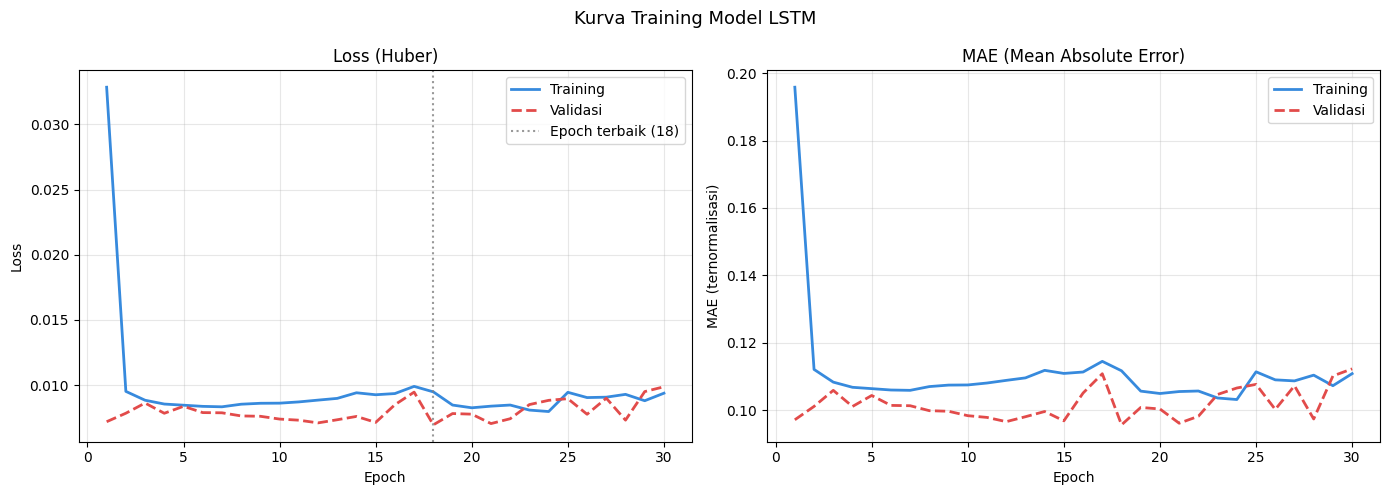

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history.history['loss']) + 1)

# Plot Loss
axes[0].plot(ep, history.history['loss'],     label='Training', color='#378ADD', lw=2)
axes[0].plot(ep, history.history['val_loss'], label='Validasi',  color='#E24B4A', lw=2, linestyle='--')
axes[0].axvline(best_epoch, color='gray', linestyle=':', alpha=0.8, label=f'Epoch terbaik ({best_epoch})')
axes[0].set_title('Loss (Huber)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(ep, history.history['mae'],     label='Training', color='#378ADD', lw=2)
axes[1].plot(ep, history.history['val_mae'], label='Validasi',  color='#E24B4A', lw=2, linestyle='--')
axes[1].set_title('MAE (Mean Absolute Error)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (ternormalisasi)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Kurva Training Model LSTM', fontsize=13)
plt.tight_layout()
plt.savefig('kurva_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Sel 9 — Evaluasi pada Data Test

In [38]:
# ===== PREDIKSI =====
y_pred_scaled = model.predict(X_test, verbose=0)

# Kembalikan ke skala asli (partikel/m³)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# ===== METRIK EVALUASI =====
y_pred_flat = y_pred.flatten()
y_true_flat = y_true.flatten()

rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mae  = mean_absolute_error(y_true_flat, y_pred_flat)
r2   = r2_score(y_true_flat, y_pred_flat)
mape = mean_absolute_percentage_error(y_true_flat, y_pred_flat) * 100

print('=' * 50)
print('  Hasil Evaluasi Model LSTM')
print('  Data: Test Set (15% terakhir)')
print('=' * 50)
print(f'  RMSE  : {rmse:.2f}  partikel/m³')
print(f'  MAE   : {mae:.2f}  partikel/m³')
print(f'  MAPE  : {mape:.2f} %')
print(f'  R²    : {r2:.4f}')
print('=' * 50)

# Interpretasi R²
if r2 >= 0.90:
    ket = 'Sangat baik'
elif r2 >= 0.75:
    ket = 'Baik'
elif r2 >= 0.50:
    ket = 'Cukup'
else:
    ket = 'Perlu perbaikan'
print(f'  Interpretasi R²: {ket}')

# Evaluasi per horizon (jam ke-1 vs jam ke-24)
print('\nAkurasi per Jam Prediksi ke Depan:')
print(f'{"Jam":>6} {"RMSE":>10} {"MAE":>10} {"R2":>8}')
print('-' * 40)
for h in [1, 6, 12, 18, 24]:
    idx = h - 1
    if idx < HORIZON:
        r = np.sqrt(mean_squared_error(y_true[:, idx], y_pred[:, idx]))
        m = mean_absolute_error(y_true[:, idx], y_pred[:, idx])
        r2h = r2_score(y_true[:, idx], y_pred[:, idx])
        print(f'{h:>6} {r:>10.2f} {m:>10.2f} {r2h:>8.4f}')

  Hasil Evaluasi Model LSTM
  Data: Test Set (15% terakhir)
  RMSE  : 73.54  partikel/m³
  MAE   : 59.00  partikel/m³
  MAPE  : 14.53 %
  R²    : -0.1390
  Interpretasi R²: Perlu perbaikan

Akurasi per Jam Prediksi ke Depan:
   Jam       RMSE        MAE       R2
----------------------------------------
     1      74.79      59.98  -0.1558
     6      76.73      61.82  -0.2129
    12      77.10      61.82  -0.2272
    18      78.24      62.81  -0.2623
    24      76.36      61.56  -0.1984


## Sel 10 — Visualisasi Prediksi vs Aktual

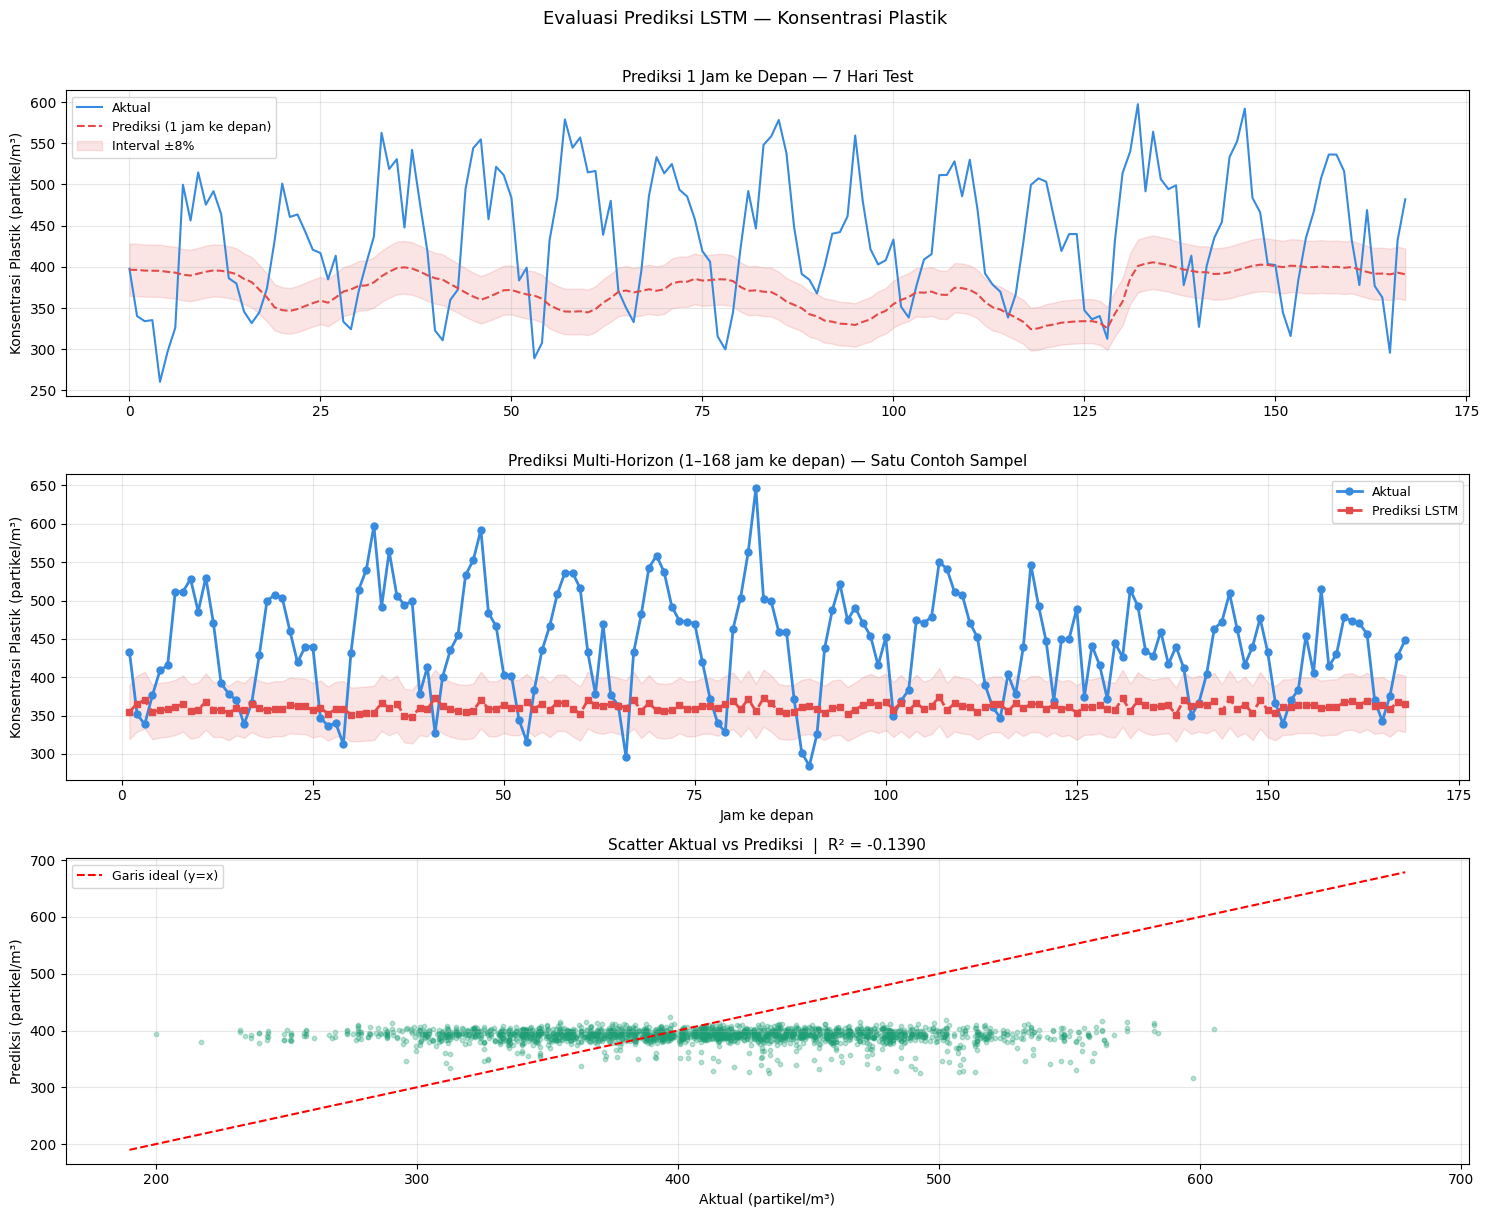

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# ---- Plot 1: Prediksi 7 hari penuh ----
n_plot = 7 * 24
jam_ke = np.arange(n_plot)

# Ambil prediksi jam ke-1 (1 langkah ke depan)
y_pred_1h = y_pred[:n_plot, 0]
y_true_1h = y_true[:n_plot, 0]

axes[0].plot(jam_ke, y_true_1h, label='Aktual',   color='#378ADD', lw=1.5)
axes[0].plot(jam_ke, y_pred_1h, label='Prediksi (1 jam ke depan)',
             color='#E24B4A', lw=1.5, linestyle='--')
axes[0].fill_between(jam_ke,
    y_pred_1h * 0.92, y_pred_1h * 1.08,
    alpha=0.15, color='#E24B4A', label='Interval ±8%')
axes[0].set_title('Prediksi 1 Jam ke Depan — 7 Hari Test', fontsize=11)
axes[0].set_ylabel('Konsentrasi Plastik (partikel/m³)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Multi-horizon (1, 6, 12, 24 jam) dari 1 titik ----
contoh_idx = 100  # ambil sampel ke-100 dari test set
jam_horizon = np.arange(1, HORIZON + 1)

axes[1].plot(jam_horizon, y_true[contoh_idx], 'o-',
             label='Aktual', color='#378ADD', lw=2, markersize=5)
axes[1].plot(jam_horizon, y_pred[contoh_idx], 's--',
             label='Prediksi LSTM', color='#E24B4A', lw=2, markersize=5)
axes[1].fill_between(jam_horizon,
    y_pred[contoh_idx] * 0.90, y_pred[contoh_idx] * 1.10,
    alpha=0.15, color='#E24B4A')
axes[1].set_title(f'Prediksi Multi-Horizon (1–{HORIZON} jam ke depan) — Satu Contoh Sampel', fontsize=11)
axes[1].set_xlabel('Jam ke depan')
axes[1].set_ylabel('Konsentrasi Plastik (partikel/m³)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ---- Plot 3: Scatter aktual vs prediksi ----
n_scatter = min(2000, len(y_true_flat))
idx_scatter = np.random.choice(len(y_true_flat), n_scatter, replace=False)

axes[2].scatter(y_true_flat[idx_scatter], y_pred_flat[idx_scatter],
                alpha=0.3, s=10, color='#1D9E75')
lim_min = min(y_true_flat.min(), y_pred_flat.min()) * 0.95
lim_max = max(y_true_flat.max(), y_pred_flat.max()) * 1.05
axes[2].plot([lim_min, lim_max], [lim_min, lim_max],
             'r--', lw=1.5, label='Garis ideal (y=x)')
axes[2].set_xlabel('Aktual (partikel/m³)')
axes[2].set_ylabel('Prediksi (partikel/m³)')
axes[2].set_title(f'Scatter Aktual vs Prediksi  |  R² = {r2:.4f}', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Evaluasi Prediksi LSTM — Konsentrasi Plastik', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hasil_prediksi_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

## Sel 11 — Analisis Residual & Distribusi Error

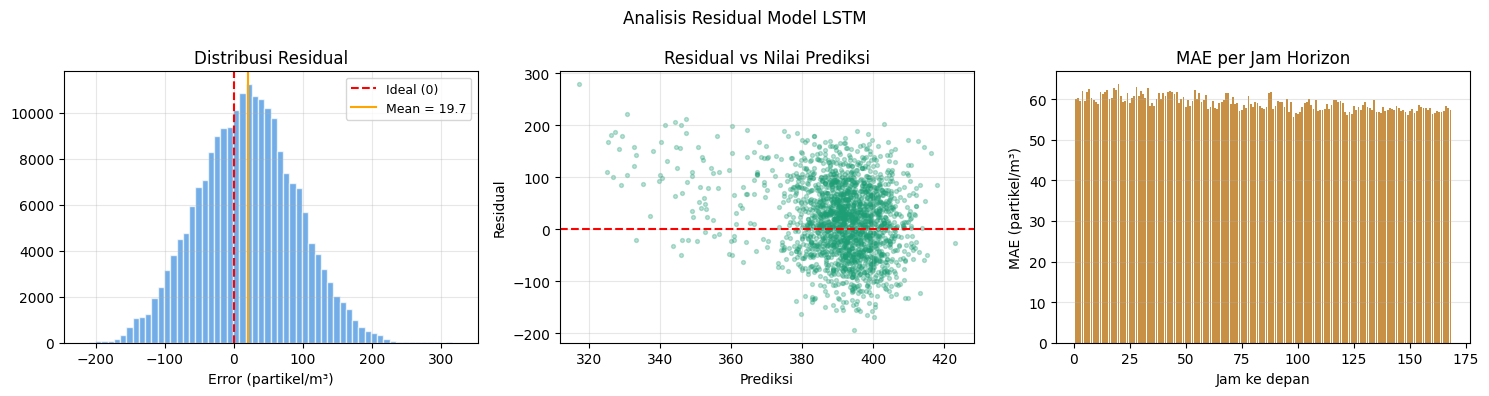


Statistik Residual:
  Mean  : 19.737 (idealnya mendekati 0)
  Std   : 70.842
  Min   : -219.049
  Max   : 325.289


In [40]:
residual = y_true_flat - y_pred_flat

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi residual
axes[0].hist(residual, bins=60, color='#378ADD', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', lw=1.5, linestyle='--', label='Ideal (0)')
axes[0].axvline(residual.mean(), color='orange', lw=1.5,
                label=f'Mean = {residual.mean():.1f}')
axes[0].set_title('Distribusi Residual')
axes[0].set_xlabel('Error (partikel/m³)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Residual vs Prediksi (cek homoskedastisitas)
axes[1].scatter(y_pred_flat[idx_scatter], residual[idx_scatter],
                alpha=0.3, s=8, color='#1D9E75')
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_title('Residual vs Nilai Prediksi')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

# Error per horizon
mae_per_h = [mean_absolute_error(y_true[:, h], y_pred[:, h])
             for h in range(HORIZON)]
axes[2].bar(range(1, HORIZON+1), mae_per_h, color='#BA7517', alpha=0.8)
axes[2].set_title('MAE per Jam Horizon')
axes[2].set_xlabel('Jam ke depan')
axes[2].set_ylabel('MAE (partikel/m³)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Analisis Residual Model LSTM', fontsize=12)
plt.tight_layout()
plt.savefig('analisis_residual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStatistik Residual:')
print(f'  Mean  : {residual.mean():.3f} (idealnya mendekati 0)')
print(f'  Std   : {residual.std():.3f}')
print(f'  Min   : {residual.min():.3f}')
print(f'  Max   : {residual.max():.3f}')

## Sel 12 — Fungsi Prediksi Real-Time (Inferensi)

Prediksi Konsentrasi Plastik 24 Jam ke Depan:
  2026-01-01 00:00 :   383.3 partikel/m³  [SEDANG]
  2026-01-01 01:00 :   385.0 partikel/m³  [SEDANG]
  2026-01-01 02:00 :   387.8 partikel/m³  [SEDANG]
  2026-01-01 03:00 :   381.1 partikel/m³  [SEDANG]
  2026-01-01 04:00 :   393.5 partikel/m³  [SEDANG]
  2026-01-01 05:00 :   381.7 partikel/m³  [SEDANG]
  2026-01-01 06:00 :   380.3 partikel/m³  [SEDANG]
  2026-01-01 07:00 :   386.1 partikel/m³  [SEDANG]
  2026-01-01 08:00 :   385.3 partikel/m³  [SEDANG]
  2026-01-01 09:00 :   387.1 partikel/m³  [SEDANG]
  2026-01-01 10:00 :   391.8 partikel/m³  [SEDANG]
  2026-01-01 11:00 :   377.2 partikel/m³  [SEDANG]
  2026-01-01 12:00 :   378.9 partikel/m³  [SEDANG]
  2026-01-01 13:00 :   377.0 partikel/m³  [SEDANG]
  2026-01-01 14:00 :   376.8 partikel/m³  [SEDANG]
  2026-01-01 15:00 :   390.9 partikel/m³  [SEDANG]
  2026-01-01 16:00 :   389.3 partikel/m³  [SEDANG]
  2026-01-01 17:00 :   378.9 partikel/m³  [SEDANG]
  2026-01-01 18:00 :   380.6 partike

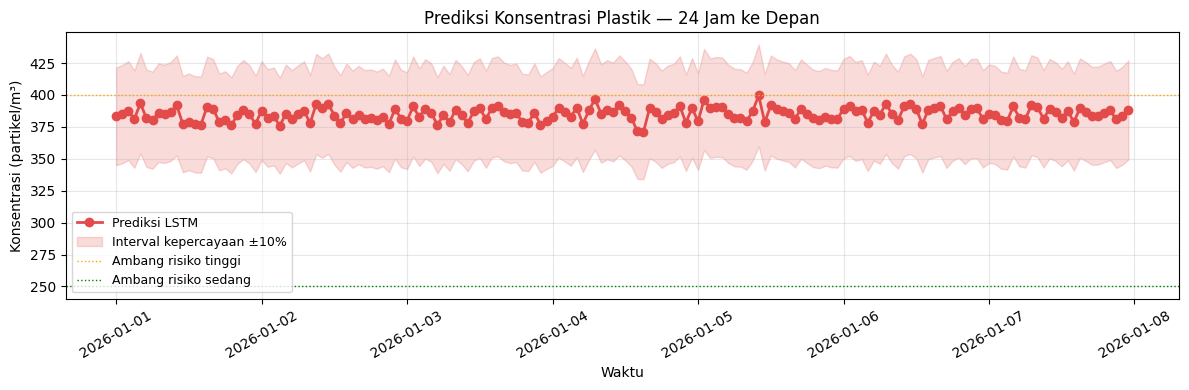

In [41]:
def prediksi_dari_data_terbaru(
    df_input,
    model,
    scaler_X,
    scaler_y,
    fitur_input,
    window=48,
    horizon=24
):
    """
    Melakukan prediksi konsentrasi plastik menggunakan
    data terbaru dari sensor lapangan.

    Parameter:
    - df_input : DataFrame dengan minimal `window` baris terbaru
    - model    : model LSTM yang sudah dilatih
    - scaler_X, scaler_y : scaler yang digunakan saat training
    - fitur_input : list nama kolom fitur
    - window, horizon : harus sama dengan saat training

    Return:
    - prediksi : array [horizon] nilai konsentrasi plastik
    - waktu    : DatetimeIndex untuk setiap jam prediksi
    """
    # Ambil window terbaru
    data_terbaru = df_input[fitur_input].values[-window:]

    # Normalisasi
    data_scaled = scaler_X.transform(data_terbaru)

    # Reshape ke (1, window, n_fitur)
    X_input = data_scaled.reshape(1, window, len(fitur_input))

    # Prediksi
    pred_scaled = model.predict(X_input, verbose=0)
    prediksi    = scaler_y.inverse_transform(pred_scaled)[0]

    # Buat index waktu
    waktu_terakhir = df_input.index[-1]
    waktu_prediksi = pd.date_range(
        start=waktu_terakhir + pd.Timedelta(hours=1),
        periods=horizon,
        freq='1h'
    )

    return prediksi, waktu_prediksi


# ===== CONTOH PREDIKSI MENGGUNAKAN DATA TERBARU =====
prediksi_besok, waktu_besok = prediksi_dari_data_terbaru(
    df_input     = df,
    model        = model,
    scaler_X     = scaler_X,
    scaler_y     = scaler_y,
    fitur_input  = FITUR_INPUT,
    window       = WINDOW,
    horizon      = HORIZON
)

# Tampilkan hasil
print('Prediksi Konsentrasi Plastik 24 Jam ke Depan:')
print('=' * 50)
for t, p in zip(waktu_besok, prediksi_besok):
    risiko = 'TINGGI' if p > 400 else ('SEDANG' if p > 250 else 'RENDAH')
    print(f'  {t.strftime("%Y-%m-%d %H:%M")} : {p:7.1f} partikel/m³  [{risiko}]')

# Visualisasi prediksi
plt.figure(figsize=(12, 4))
plt.plot(waktu_besok, prediksi_besok, 'o-',
         color='#E24B4A', lw=2, markersize=6, label='Prediksi LSTM')
plt.fill_between(waktu_besok,
    prediksi_besok * 0.90, prediksi_besok * 1.10,
    alpha=0.2, color='#E24B4A', label='Interval kepercayaan ±10%')
plt.axhline(400, color='orange', lw=1, linestyle=':', label='Ambang risiko tinggi')
plt.axhline(250, color='green',  lw=1, linestyle=':', label='Ambang risiko sedang')
plt.title('Prediksi Konsentrasi Plastik — 24 Jam ke Depan', fontsize=12)
plt.xlabel('Waktu')
plt.ylabel('Konsentrasi (partikel/m³)')
plt.xticks(rotation=30)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediksi_24jam.png', dpi=150, bbox_inches='tight')
plt.show()

## Sel 13 — Simpan Semua Hasil

In [42]:
import json

# ===== SIMPAN MODEL =====
model.save('lstm_hidrodinamika_final.h5')
print('Model tersimpan: lstm_hidrodinamika_final.h5')

# ===== SIMPAN DATA SINTETIS =====
df.to_csv('data_hidrodinamika_sintetis.csv')
print('Data CSV tersimpan: data_hidrodinamika_sintetis.csv')

# ===== SIMPAN HISTORY TRAINING =====
history_dict = {k: [float(v) for v in vals]
                for k, vals in history.history.items()}
with open('training_history.json', 'w') as f:
    json.dump(history_dict, f)
print('History tersimpan: training_history.json')

# ===== SIMPAN METRIK =====
metrik = {
    'rmse_test' : float(rmse),
    'mae_test'  : float(mae),
    'mape_test' : float(mape),
    'r2_test'   : float(r2),
    'window'    : WINDOW,
    'horizon'   : HORIZON,
    'n_fitur'   : n_fitur,
    'fitur_input': FITUR_INPUT
}
with open('metrik_evaluasi.json', 'w') as f:
    json.dump(metrik, f, indent=2)
print('Metrik tersimpan: metrik_evaluasi.json')

# ===== OPSIONAL: Simpan ke Google Drive =====
print('\n--- Untuk simpan ke Google Drive, jalankan sel berikut ---')

# Ringkasan akhir
print('\n' + '=' * 55)
print('  RINGKASAN AKHIR')
print('=' * 55)
print(f'  Model         : Bidirectional LSTM 3 layer')
print(f'  Data          : {df.shape[0]:,} jam ({df.shape[0]//24} hari)')
print(f'  Fitur input   : {n_fitur} variabel')
print(f'  Window        : {WINDOW} jam')
print(f'  Horizon       : {HORIZON} jam ke depan')
print(f'  RMSE test     : {rmse:.2f} partikel/m³')
print(f'  MAE test      : {mae:.2f} partikel/m³')
print(f'  R² test       : {r2:.4f}')
print('=' * 55)

Model tersimpan: lstm_hidrodinamika_final.h5
Data CSV tersimpan: data_hidrodinamika_sintetis.csv
History tersimpan: training_history.json
Metrik tersimpan: metrik_evaluasi.json

--- Untuk simpan ke Google Drive, jalankan sel berikut ---

  RINGKASAN AKHIR
  Model         : Bidirectional LSTM 3 layer
  Data          : 8,760 jam (365 hari)
  Fitur input   : 15 variabel
  Window        : 168 jam
  Horizon       : 168 jam ke depan
  RMSE test     : 73.54 partikel/m³
  MAE test      : 59.00 partikel/m³
  R² test       : -0.1390


In [43]:
# ===== SIMPAN KE GOOGLE DRIVE (OPSIONAL) =====
from google.colab import drive
drive.mount('/content/drive')

import shutil
folder = '/content/drive/MyDrive/LSTM_Plastik_Hidrodinamika'
os.makedirs(folder, exist_ok=True)

for file in [
    'lstm_hidrodinamika_final.h5',
    'lstm_hidrodinamika_terbaik.h5',
    'data_hidrodinamika_sintetis.csv',
    'training_history.json',
    'metrik_evaluasi.json',
    'eda_hidrodinamika.png',
    'kurva_training.png',
    'hasil_prediksi_lstm.png',
    'analisis_residual.png',
    'prediksi_24jam.png',
]:
    if os.path.exists(file):
        shutil.copy(file, f'{folder}/{file}')
        print(f'Tersimpan: {folder}/{file}')

print('\nSemua file berhasil disimpan ke Google Drive!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/lstm_hidrodinamika_final.h5
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/lstm_hidrodinamika_terbaik.h5
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/data_hidrodinamika_sintetis.csv
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/training_history.json
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/metrik_evaluasi.json
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/eda_hidrodinamika.png
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/kurva_training.png
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/hasil_prediksi_lstm.png
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/analisis_residual.png
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/prediksi_24jam.png

Semua file berhasil d